## libraries used

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## getting list of all disasters

In [2]:
csvFilename = 'philip_disas.csv'
csvDirectory = '{}'.format(csvFilename)
philip_disasters_df = pd.read_csv(csvDirectory)

disaster_types = philip_disasters_df['Disaster Type'].dropna().unique()

# Display the list
all_disasters = disaster_types.tolist()
print(all_disasters)

['Storm', 'Earthquake', 'Mass movement (wet)', 'Fire (Industrial)', 'Fire (Miscellaneous)', 'Volcanic activity', 'Flood', 'Road', 'Collapse (Miscellaneous)', 'Poisoning', 'Epidemic', 'Drought', 'Air', 'Explosion (Miscellaneous)', 'Water', 'Miscellaneous accident (General)', 'Mass movement (dry)', 'Explosion (Industrial)', 'Collapse (Industrial)', 'Infestation', 'Chemical spill', 'Rail', 'Wildfire', 'Oil spill']


## graph all disasters

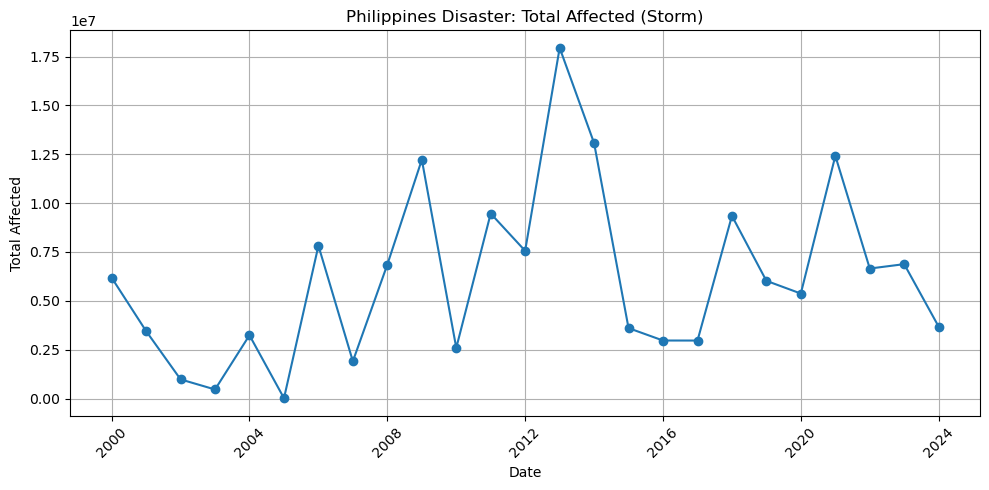

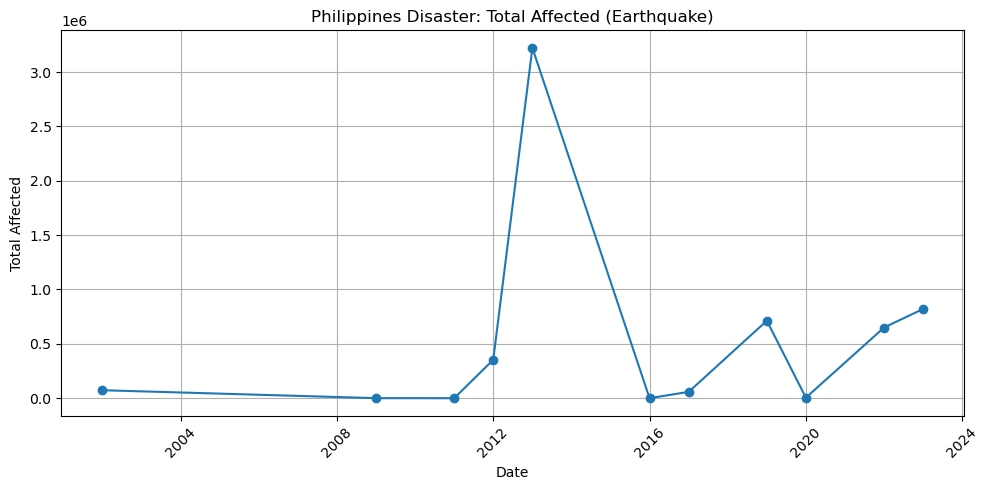

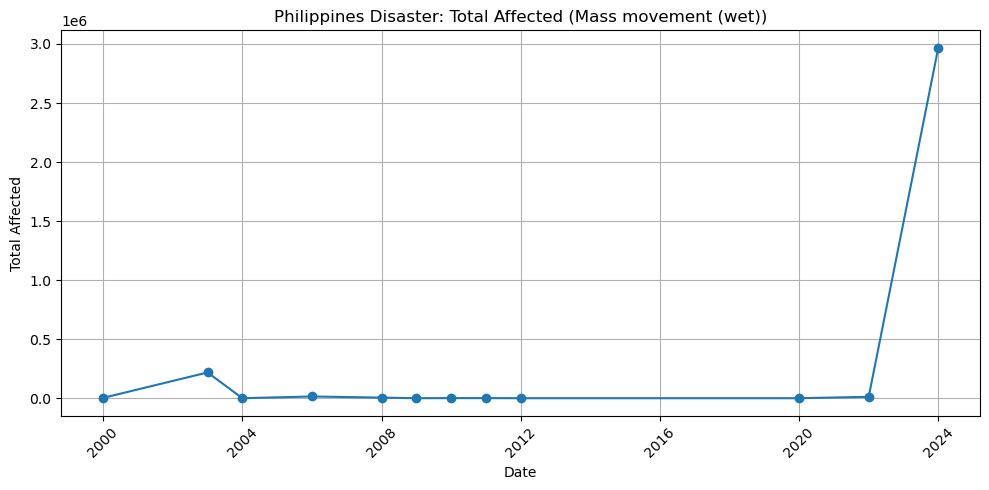

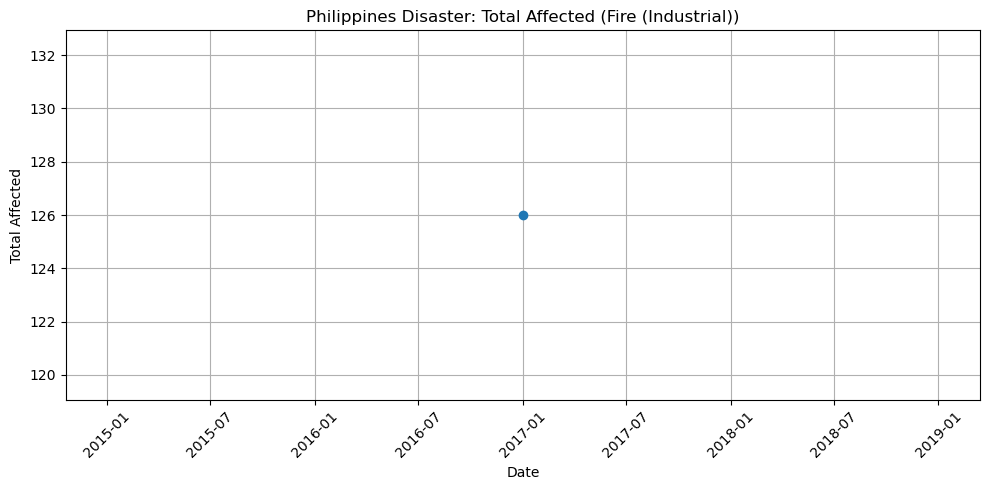

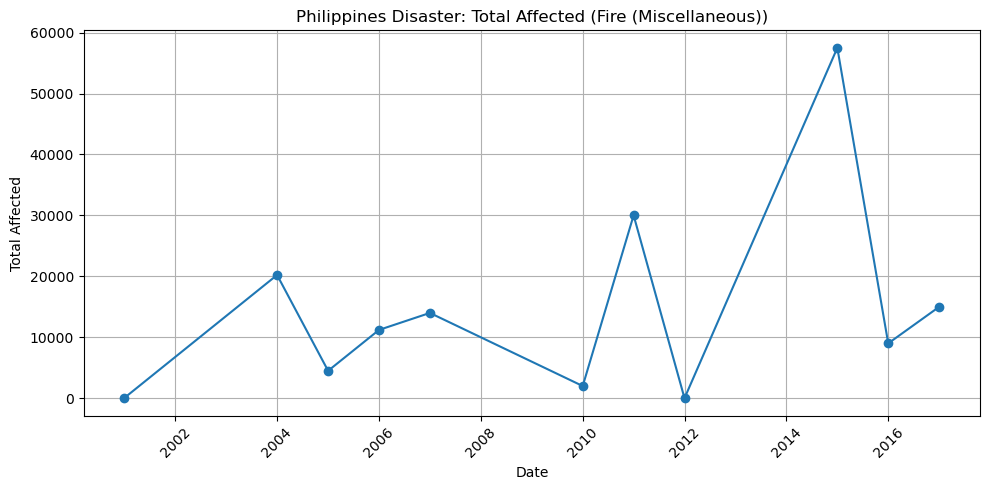

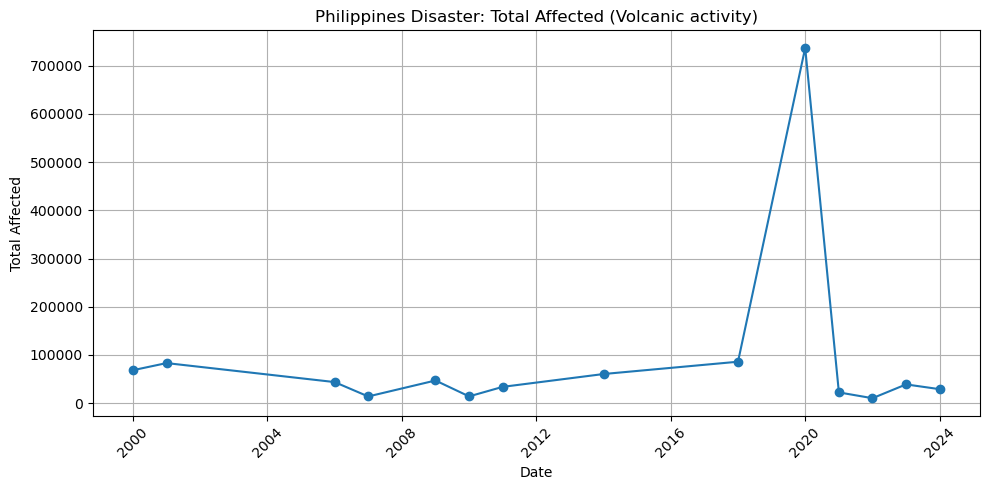

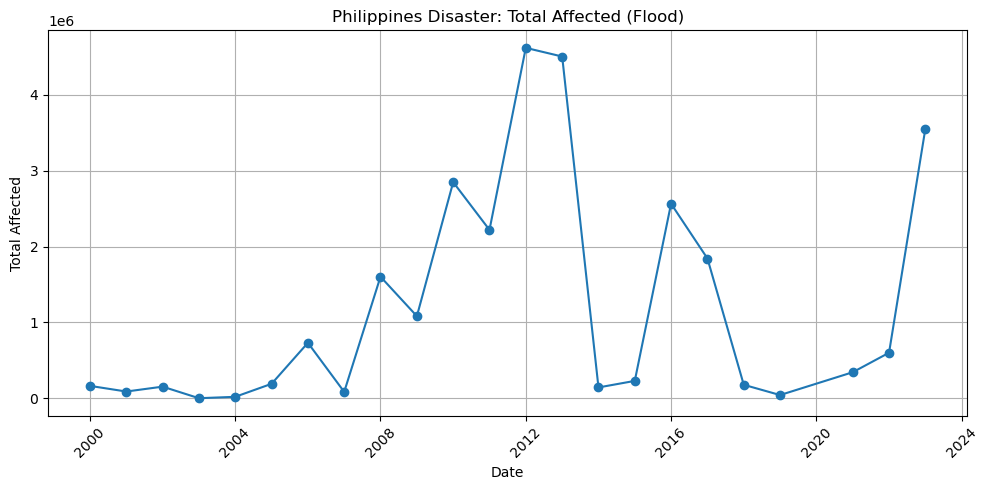

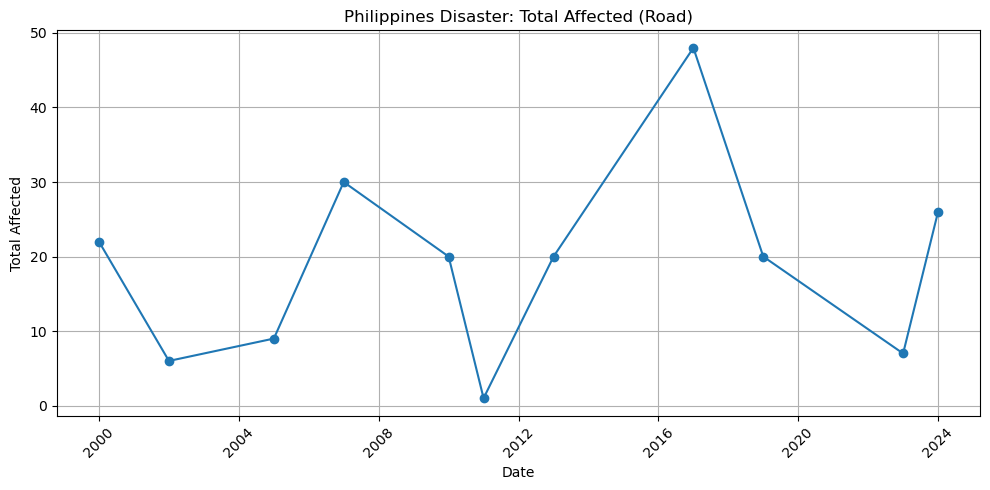

No valid data available for disaster type 'Collapse (Miscellaneous)'.
No valid data available for disaster type 'Poisoning'.


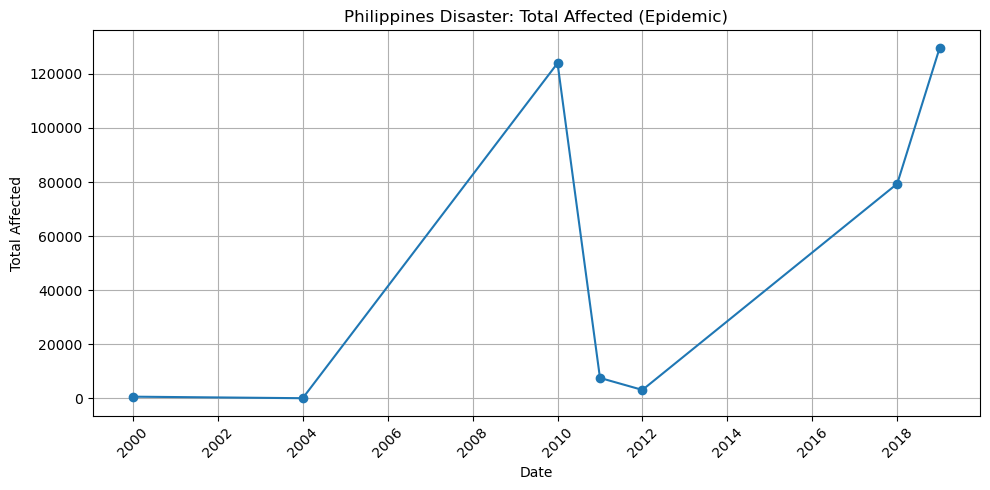

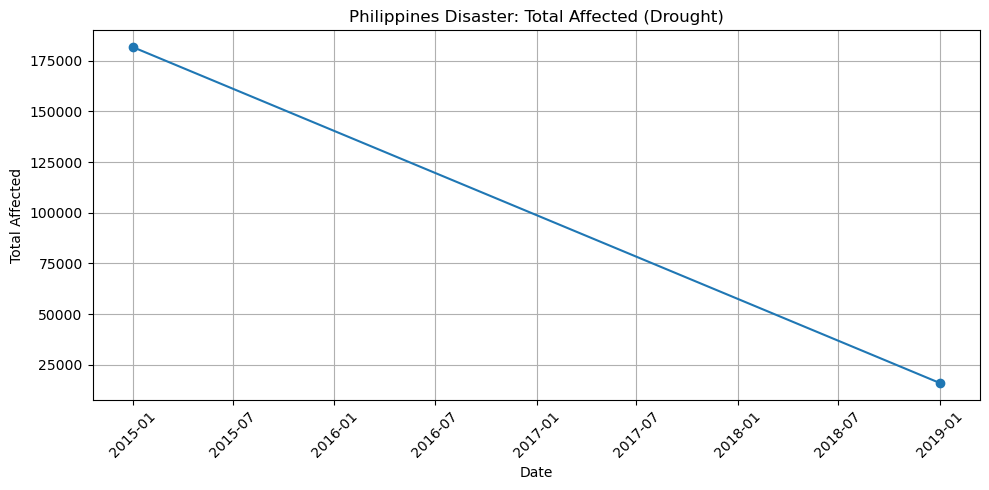

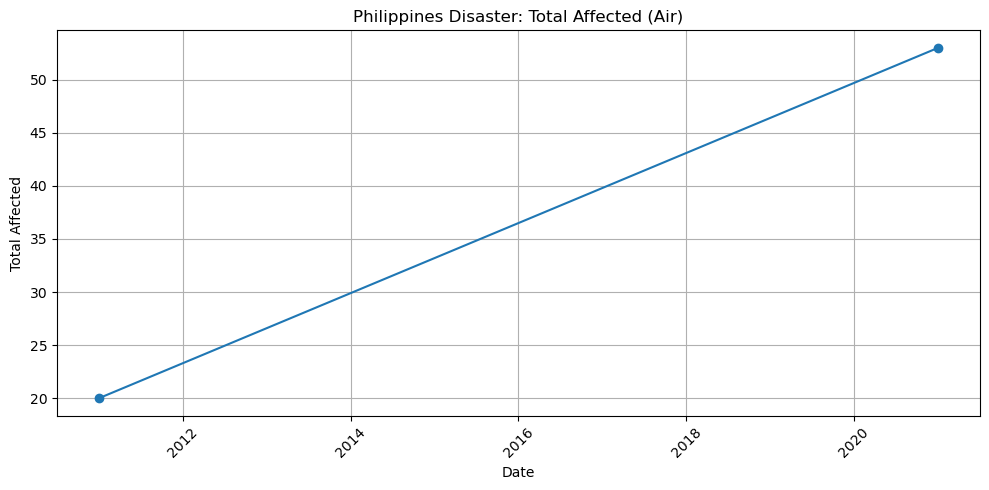

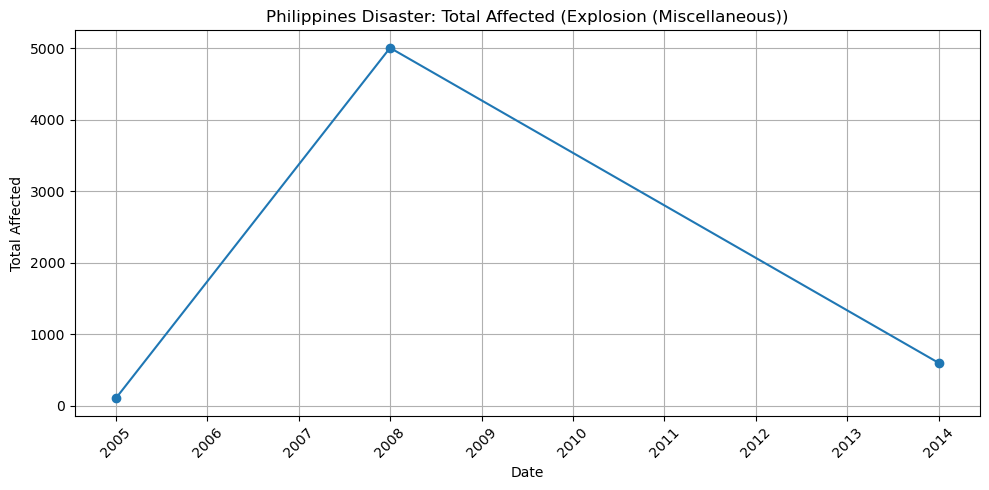

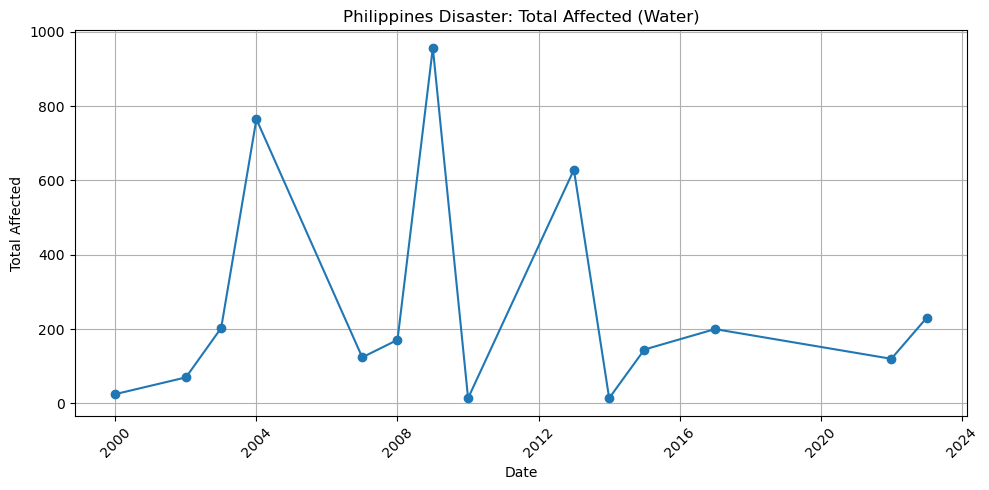

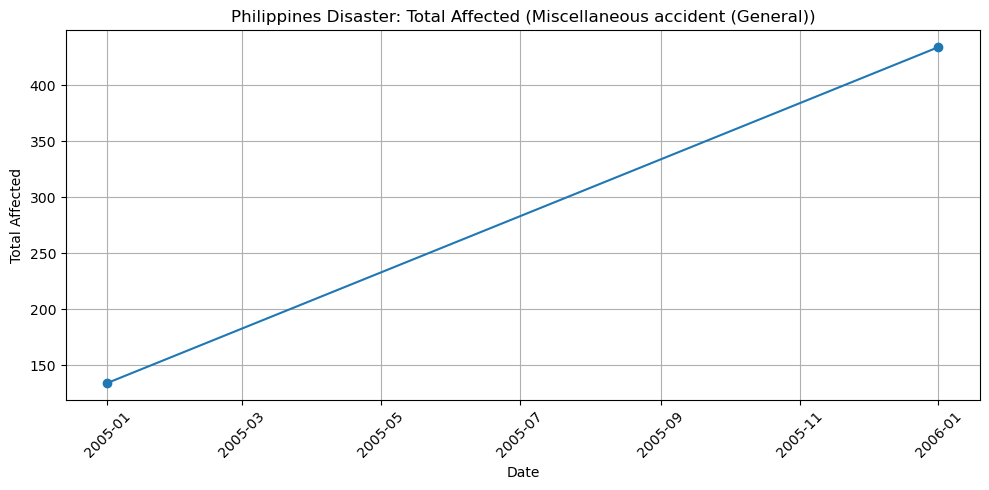

No valid data available for disaster type 'Mass movement (dry)'.
No valid data available for disaster type 'Explosion (Industrial)'.
No valid data available for disaster type 'Collapse (Industrial)'.
No valid data available for disaster type 'Infestation'.


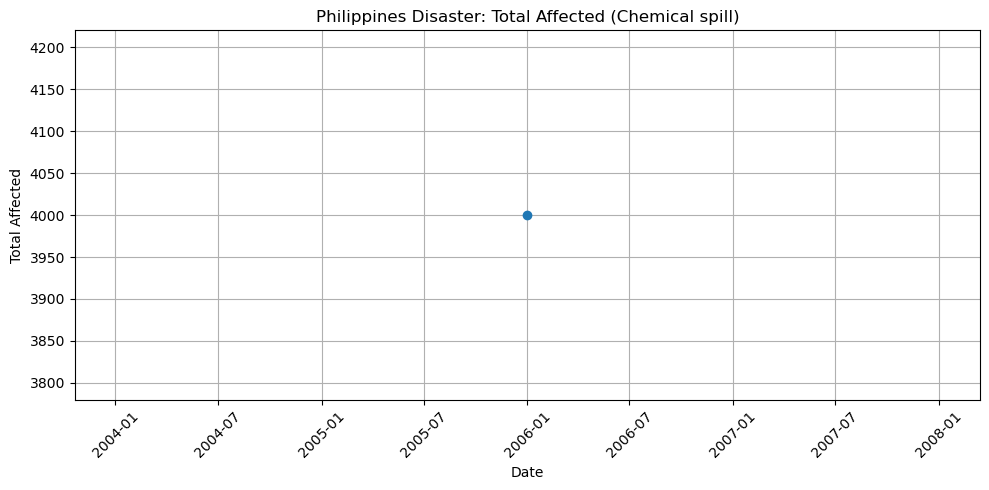

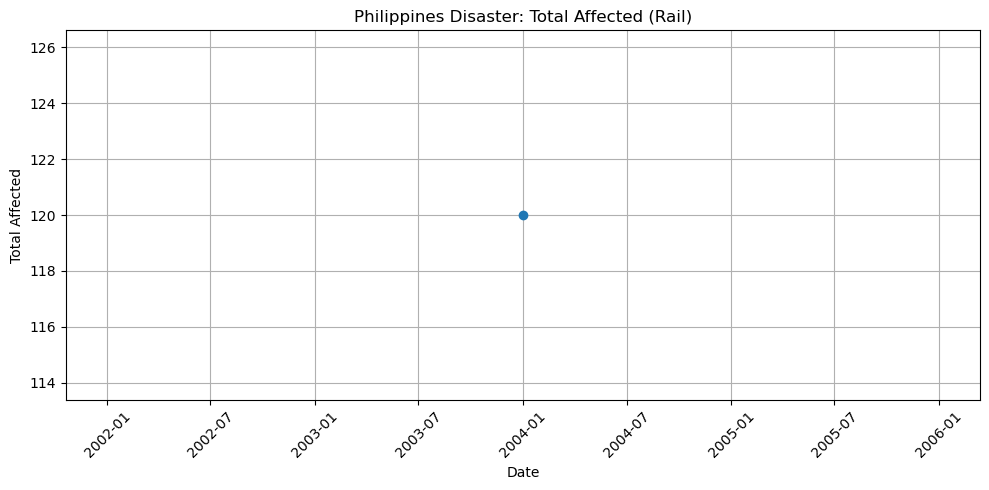

No valid data available for disaster type 'Wildfire'.


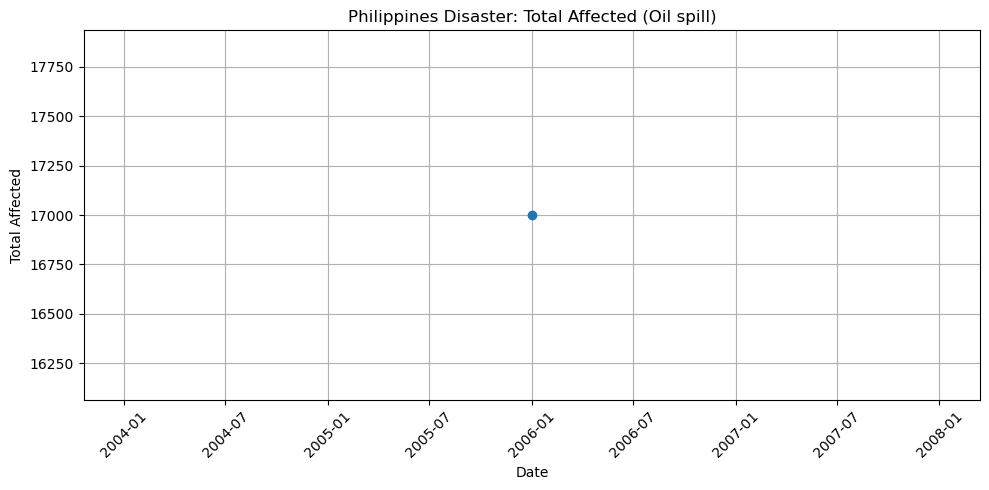

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

def graph_disaster(type):
    # Filter the required columns for the given disaster type and years 2000+
    data = philip_disasters_df[
        (philip_disasters_df['Disaster Type'] == type) & 
        philip_disasters_df['Total Affected'].notna() & 
        philip_disasters_df['Year'].notna() & 
        (philip_disasters_df['Year'] >= 2000)
    ].copy()

    # Ensure numeric type for 'Year' and 'Total Affected'
    data['Year'] = pd.to_numeric(data['Year'], errors='coerce')
    data['Total Affected'] = pd.to_numeric(data['Total Affected'], errors='coerce')

    # Create a datetime column based on 'Year'
    # Assuming the data has a 'Month' column
    if 'Month' not in data.columns:
        data['Month'] = 1  # Default to January if 'Month' is missing

    data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(Day=1), errors='coerce')

    # Drop rows with invalid data
    data = data.dropna(subset=['Date', 'Total Affected'])

    # Group by 2-month intervals
    if not data.empty:
        data['Date Group'] = data['Date'].dt.to_period('2M').dt.start_time
        grouped_data = data.groupby('Date Group')['Total Affected'].sum().reset_index()

        if not grouped_data.empty:
            # Plot the graph
            plt.figure(figsize=(10, 5))
            plt.plot(grouped_data['Date Group'], grouped_data['Total Affected'], marker='o')
            plt.xlabel('Date')
            plt.ylabel('Total Affected')
            plt.title('Philippines Disaster: Total Affected ({})'.format(type))
            plt.xticks(rotation=45)
            plt.grid()
            plt.tight_layout()
            plt.show()
        else:
            print(f"No data available for disaster type '{type}' after grouping.")
    else:
        print(f"No valid data available for disaster type '{type}'.")

for dis in all_disasters:
    graph_disaster(dis)